# Diffusion Quantum Monte Carlo for Ground State Energy Estimation

## Context and Motivation

Quantum Monte Carlo (QMC) methods constitute a powerful class of stochastic techniques for solving quantum many-body problems beyond the reach of exact analytical approaches. Among these, Diffusion Quantum Monte Carlo (DMC) stands out for its ability to project out the ground state of a quantum system with controlled approximations.

The DMC method combines diffusion, branching, and population control to simulate the imaginary-time evolution of a quantum system. By tracking the statistical properties of the walker population and the evolution of $ V_{ref} $, one can extract the ground state energy and spatial distribution of the system.

## Theoretical Background

The starting point of Diffusion Quantum Monte Carlo is the time-dependent Schrödinger equation expressed in imaginary time. Under the transformation $ t \rightarrow -i\tau $, the equation becomes a diffusion-like equation with a potential-dependent source term.

In this formulation, the evolution operator exponentially suppresses higher-energy states, such that in the long-time limit ( $\tau \to \infty $), the wavefunction converges to the ground state of the system. This projection property forms the theoretical foundation of the DMC method.

The resulting equation can be interpreted probabilistically, allowing the wavefunction to be represented by a population of random walkers undergoing diffusion and branching processes.


## Objectives of the Project

The primary objective of this project is to implement a Diffusion Quantum Monte Carlo algorithm in order to estimate the ground state energy of one-dimensional quantum systems.

The project will proceed through the following steps:

- Implementation of the DMC algorithm using a population of walkers evolving in imaginary time.
- Validation of the method on the harmonic oscillator potential, for which the exact ground state energy is known.
- Extension to anharmonic potentials, exploring how deviations from quadratic confinement affect the ground state energy and spatial distribution.
- Investigation of time-step errors and extrapolation to the zero time-step limit.

In [60]:
import numpy as np
import matplotlib.pyplot as plt

---

## Theoretical Framework

### Imaginary Time

The imaginary time $ \tau $ is defined through the Wick rotation $ t \rightarrow -i\tau $. In this framework, the Schrödinger equation takes the form of a diffusion equation:

$$
\frac{\partial \psi(x,\tau)}{\partial \tau} = D \nabla^2 \psi(x,\tau) - (V(x) - V_{ref}) \psi(x,\tau)
$$

where $ D = \frac{1}{2} $ in the chosen system of units ($ \hbar = m = 1 $).

### Random Walkers

The wavefunction $ \psi(x,\tau) $ is represented by a discrete set of configurations called *walkers*. Each walker corresponds to a point in configuration space and evolves stochastically over time.

The dynamics of walkers consists of two processes:

- **Diffusion:** random displacements drawn from a Gaussian distribution.
- **Branching:** replication or deletion depending on the local potential energy.

### Reference Energy $ V_{ref} $

The reference energy $ V_{ref} $ is a dynamically adjusted parameter introduced to control the total number of walkers. It effectively shifts the potential and determines whether walkers are more likely to reproduce or die.

Its value is updated during the simulation to stabilize the population around a target value. In the long-time limit, $ V_{ref} $ converges to the ground state energy of the system.

### Target Population $ N_0 $

The quantity $N_0$ denotes the desired number of walkers in the simulation. Due to the stochastic nature of the branching process, the actual number of walkers fluctuates around this value.

A feedback mechanism involving $ V_{ref} $ ensures that the population remains close to $ N_0 $, preventing numerical instabilities such as exponential growth or extinction.


### Time Step $ \Delta\tau $

The imaginary time is discretized into finite steps $\Delta\tau $. The accuracy of the simulation depends on this parameter: smaller values reduce systematic errors but increase computational cost.

A careful analysis of the $ \Delta\tau \to 0 $ limit is therefore required to obtain reliable physical results.

In [61]:
N0 = 20000

dtau = 0.0005
Nt = 2000 # on cherche a avoir Nt * dtau = 1 = temps total

a = 0.3 # pour une correction de Vref stable

def N_thermalization(Nt) : # le systeme a besoin de thermaliser avant que l'on calcul des quantitées
  return int(0.25 * Nt)

---

## Walker diffusion

Each walker follows:
$$x_i \leftarrow x_i + \eta, \quad \eta \sim N(0, \sqrt{\Delta \tau}) $$

The diffusion corresponds to the kinetic term, so the larger $\Delta \tau$ is, the more the walkers spread out.

In [62]:
def diffuse(walkers : np.ndarray, dtau : float) -> np.ndarray :
  return walkers + np.random.normal(0, np.sqrt(dtau), size=walkers.shape)

---

## Potentials

We will test this method in our simulation using several potentials:

### Harmonic

$$V(x) = \frac{1}{2} x^2$$

- $E_0 = \frac 1 2$
- $\psi_{harm} \propto e^{-x^2/2}$

### Anharmonique Cubique
$$V(x) = \frac{1}{2} x^2 + bx^3$$

- $E_0 = \frac 1 2 - \frac{11} 8 b^2$
- $\psi_{cub} \propto \psi_{harm} - b(\frac 3 {2 \sqrt 2} \psi_1(x) + \frac 1{2 \sqrt{6}}\psi_3(x))$

with $\psi_1 \propto xe^{-x^2/2}$ and $\psi_3 \propto (8x^3-12x)e^{-x^2/2}$.

### Anharmonique Quartic
$$V(x) = \frac{1}{2} x^2 + bx^4$$

- $E_0 = \frac 1 2 + \frac{3} 4 b- \frac{21} 8 b^2$
- $\psi_{quart} \propto \psi_{harm} - b(\frac 3 {2 \sqrt 2} \psi_2(x) + \frac {\sqrt 6}{8}\psi_3(x))$

with $\psi_2 \propto (4x^2-2)e^{-x^2/2}$ and $\psi_3 \propto (16x^4-48x^2+12)e^{-x^2/2}$.


In [63]:
global b, V_list

b = 0.1
V_list = ["Harmonic", "Anharmonic Cubic", "Anharmonic Quartic"]

# Potential
def V(x, kind:str="Harmonic"):
    if kind == "Harmonic":
        return 0.5 * x**2
    elif kind == "Anharmonic Cubic":
        return 0.5 * x**2 + b * x**3
    elif kind == "Anharmonic Quartic":
        return 0.5 * x**2 + b * x**4

def exp_harm(x) :
  return np.exp(-x**2/2)

def compute_psi_harm(x) :
  exp_h = exp_harm(x)
  N = (1/np.pi)**0.25
  return N * exp_h

def compute_x(walkers) :
  xmax = np.max(np.abs(walkers))
  return np.linspace(-xmax, xmax, 200)

def compute_theoric_value(walkers) :
  ## energy
  E0_list = [0.5, 1/2-(11*(b**2)/8), 1/2+((3*b)/4)-((21*(b**2))/8)]
  E0_theoric = {}
  for potential_name, E0 in zip(V_list, E0_list):
    E0_theoric[potential_name] = E0

  ## wavefunctions
  psi0_theoric, x_dic = {}, {}

  for potential_name in V_list :
    x = compute_x(walkers[potential_name])

    psi_harm = compute_psi_harm(x)
    exp_h = exp_harm(x)

    if potential_name == "Harmonic":
      psi0 = psi_harm

    elif potential_name == "Anharmonic Cubic":
      psi_1 = (np.sqrt(2) / np.pi**0.25) * x * exp_h

      psi_3 = (1 / np.sqrt(48 * np.sqrt(np.pi))) * (8*x**3 - 12*x) * exp_h

      psi_cub = psi_harm - b * ( (3 / (2 * np.sqrt(2))) * psi_1 + (1 / (2 * np.sqrt(6))) * psi_3 )
      psi0 = psi_cub / np.sqrt(np.trapz(psi_cub**2, x))

    elif potential_name == "Anharmonic Quartic":
      psi_2 = (1 / (np.sqrt(8 * np.sqrt(np.pi)))) * (4*x**2 - 2) * exp_h

      psi_4 = (1 / (np.sqrt(384 * np.sqrt(np.pi)))) * (16*x**4 - 48*x**2 + 12) * exp_h

      psi_quart = psi_harm - b * ( (3 / (2 * np.sqrt(2))) * psi_2 + (np.sqrt(6) / 8) * psi_4 )
      psi0 = psi_quart / np.sqrt(np.trapz(psi_quart**2, x))
    x_dic[potential_name] = x
    psi0_theoric[potential_name] = psi0

  return E0_theoric, psi0_theoric, x_dic

---

## Branching

Each walker has a weight:

$$w_i = e^{-(V(x_i)-V_{ref})\Delta \tau}$$

- $w_i > 1 \rightarrow$ reproduction
- $w_i < 1 \rightarrow$ likely extinction

For each walker, we will:
- calculate $w_i$ and $n_i=⌊w_i⌋$,
- generate a random number $r \in [0,1]$,
- if $r < (w_i - n_i)$, we add a copy of this walker.


In [64]:
def branch(walkers : np.ndarray, Vref : float, dtau : float, potential:str="Harmonic") -> np.ndarray:
    w = np.exp(-(V(walkers, potential) - Vref) * dtau) # par defaut V(x) = oscilateur harmonique

    n = np.floor(w).astype(int)

    diff = w - n
    r = np.random.rand(len(walkers))
    extra = (r < diff).astype(int)

    copies = n + extra
    return np.repeat(walkers, copies)

---

## New reference Potential

To prevent the number of walkers from exploding or dying out, we will modify the value of $V_{ref}$ with :

$$V_{ref} = \langle V \rangle - \frac{a}{N_0 \Delta \tau}(N-N_0)$$

where: $ \langle V \rangle = \frac{1}{N} \sum_i V(x_i) $

With this, if:
- $N>N_0$ then $V_{ref} \nearrow$ fewer walkers
- $N<N_0$ then $V_{ref} \searrow$ more walkers

This allows us to have at equilibrium:
$$N \approx N_0 \implies V_{ref} \approx \langle V \rangle \approx E_0$$

Since $V_{ref}$ plays the role of $E_0$ in
$$\psi(x,\tau) \sim e^{-(H-E_0)\tau}$$

the average of $V_{ref}$ should therefore give the ground state energy $E_0$.

In [65]:
def update_Vref(walkers : np.ndarray, N0 :int, dtau : float, potential:str="Harmonic", a : float=1.) -> float:
  N = len(walkers)
  Vmean = np.mean(V(walkers, potential))
  correction = (a*(N-N0))/(N0 * dtau)
  return Vmean - correction

---

## Simulation

In [66]:
def init_simulation(N0, potential_name="Harmonic") :
  walkers = np.random.normal(0, 1, size=N0) # positions x_i
  Vref = np.mean(V(walkers, potential_name))
  return walkers, Vref

def simulation_step(walkers, Vref, N0, dtau, a, potential_name="Harmonic") :
  walkers = diffuse(walkers, dtau)
  walkers = branch(walkers, Vref, dtau, potential_name)

  Vref = update_Vref(walkers, N0, dtau, potential_name, a)
  return walkers, Vref

def simulation(N0, dtau, a, Nt) :
  N_therm = N_thermalization(Nt)
  N_list, Vref_list = {}, {}
  all_walkers = {}

  for potential_name in V_list :
    walkers, Vref = init_simulation(N0, potential_name)

    N_temp, Vref_temp, all_walkers_temp = [], [], []
    for t in range(Nt):
      walkers, Vref = simulation_step(walkers, Vref, N0, dtau, a, potential_name)
      N = len(walkers)

      # result
      Vref_temp.append(Vref)
      N_temp.append(N)
      if t > N_therm and t % 10 == 0:
        all_walkers_temp.extend(walkers)
        # stop simulation si la population de marcheur s'eloigne trop de N0
        dN = 0.005
        if N < N0*(1.-dN) or N > N0*(1.+dN):
          print(f"Simulation for {potential_name} potential break at t={t}(/{Nt}) because N={N}(/{N0})")
          break

    N_list[potential_name] = N_temp
    Vref_list[potential_name] = Vref_temp
    all_walkers[potential_name] = all_walkers_temp

  return N_list, Vref_list, all_walkers

We add a condition to prevent the **walker population from diverging**, using `dn`, which sets a maximum reachable radius that the number of walkers must not exceed; otherwise, the simulation is stopped to ensure that the $V_{ref}$ values do not diverge.

In [67]:
N_list, Vref_list, all_walkers = simulation(N0, dtau, a, Nt)

---

## Theoretical Comparison: Walkers and $\psi_0$

As we mentioned earlier:
>The wavefunction $ \psi(x,\tau) $ is represented by a discrete set of configurations called *walkers*.

In standard Quantum Mechanics, we are taught that the probability density of finding a particle at position $x$ is given by $P(x) = |\psi_0(x)|^2$. However, in a **Diffusion Monte Carlo (DMC)** simulation without importance sampling, you will observe that the histogram of your walkers matches the wavefunction $\psi_0(x)$ directly.

Indeed, the density of walkers $f(x)$ is the mathematical analog of the amplitude $\psi(x)$ in the diffusion equation. Thus, walkers congregate where $\psi_0$ is high, not $|\psi_0|^2$.

When we plot a histogram using `density=True` in Python, we are creating a **probability density function (PDF)**. By definition, the area under a PDF must equal 1:
$$\int_{-\infty}^{+\infty} \text{Histogram}(x) dx = 1$$

However, the standard theoretical wavefunction $\psi_0(x)$ is "Quantum Normalized" (the $L^2$ norm), meaning:
$$\int_{-\infty}^{+\infty} |\psi_0(x)|^2 dx = 1$$

Since our walkers sample $\psi_0(x)$ and not its square, we must **re-normalize** the theoretical expression so that its integral (the $L^1$ norm) equals 1 to match the histogram's scale:
$$\psi_{\text{theory_normalized}}(x) = \frac{\psi_0(x)}{\int \psi_0(x) dx}$$

In [68]:
E0_theoric, wavefunctions_theoric, x_dic = compute_theoric_value(all_walkers)

psi_theo_normalized = {}
for potential_name in V_list:
  psi_theo = wavefunctions_theoric[potential_name]
  psi_theo_normalized[potential_name] = psi_theo / np.trapz(psi_theo, x_dic[potential_name])

/tmp/ipykernel_279/3775092752.py:52: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  psi0 = psi_cub / np.sqrt(np.trapz(psi_cub**2, x))
/tmp/ipykernel_279/3775092752.py:60: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  psi0 = psi_quart / np.sqrt(np.trapz(psi_quart**2, x))
/tmp/ipykernel_279/428219682.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  psi_theo_normalized[potential_name] = psi_theo / np.trapz(psi_theo, x_dic[potential_name])


---

## First result

We can start testing to see if we can find $E_0$ and the associated wave function using this method for different potential.

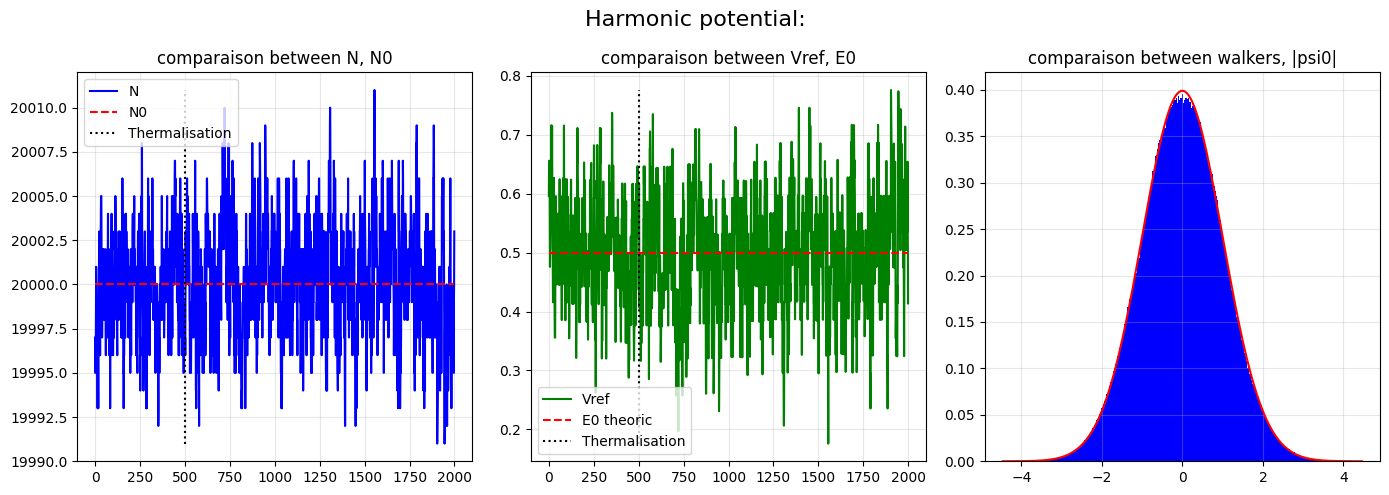

Harmonic potential:
E0 numeric = 0.494284666911676 ± 0.0024463039434364417
error : 0.005715333088324004


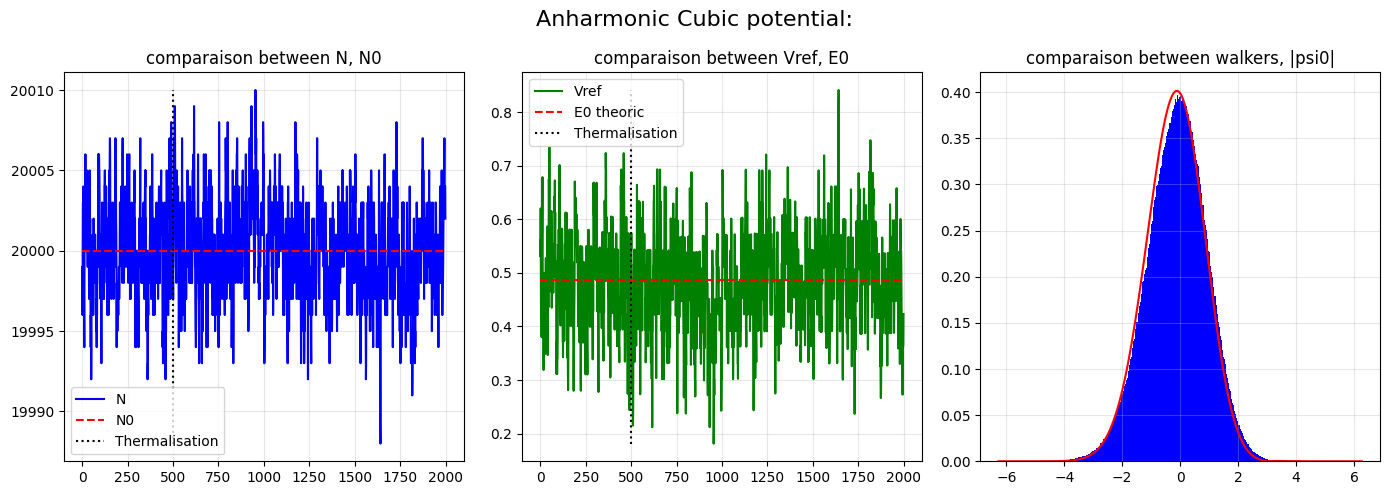

Anharmonic Cubic potential:
E0 numeric = 0.47892080734450154 ± 0.0023138524461473317
error : 0.007329192655498473


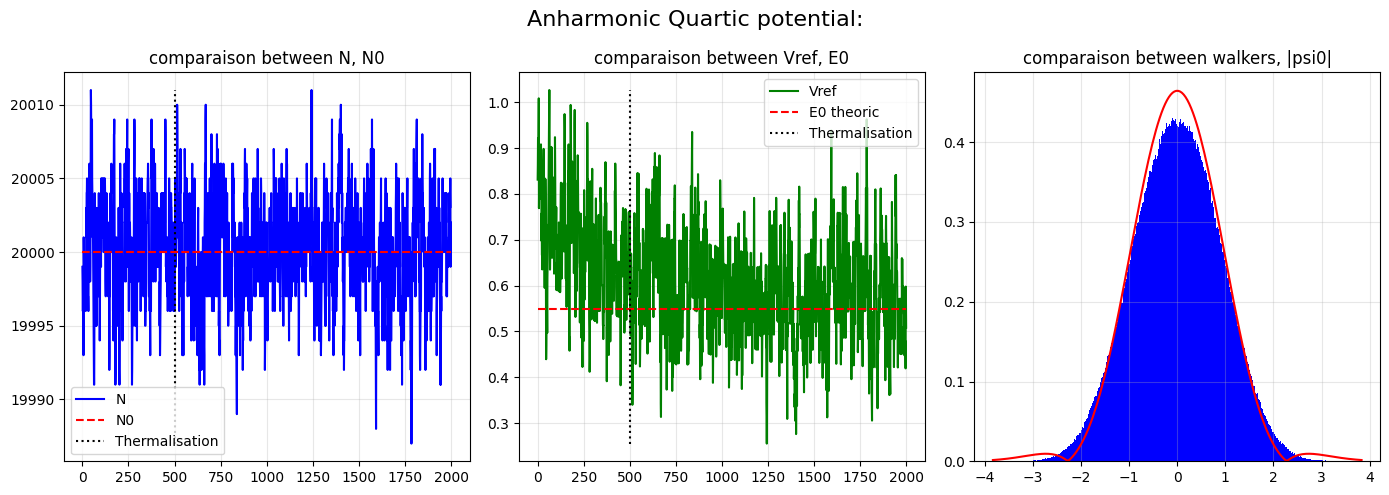

Anharmonic Quartic potential:
E0 numeric = 0.586742709237228 ± 0.002750729229083697
error : 0.037992709237228084


In [69]:
for potential_name in V_list:
  N_therm = N_thermalization(Nt)
  N = N_list[potential_name]
  Vref = Vref_list[potential_name]
  walkers = all_walkers[potential_name]

  x = x_dic[potential_name]
  psi = psi_theo_normalized[potential_name]
  E0 = E0_theoric[potential_name]

  # Plot
  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

  ax1.plot(N, color='blue', label='N')
  ax1.hlines(N0, xmin=0, xmax=Nt, colors='red', linestyles='--', label='N0')
  ax1.vlines(N_therm, ymin=min(N), ymax=max(N), colors='black', linestyles=':', label='Thermalisation')
  ax1.set_title("comparaison between N, N0")
  ax1.grid(True, alpha=0.3)

  ax2.plot(Vref, color='green', label='Vref')
  ax2.hlines(E0, xmin=0, xmax=Nt, colors='red', linestyles='--', label='E0 theoric')
  ax2.vlines(N_therm, ymin=min(Vref), ymax=max(Vref), colors='black', linestyles=':', label='Thermalisation')
  ax2.set_title("comparaison between Vref, E0")
  ax2.grid(True, alpha=0.3)

  if len(N) != Nt:
    ax1.vlines(len(N), ymin=min(N), ymax=max(N), colors='purple', linestyles='-', label='N diverge')
    ax2.vlines(len(Vref), ymin=min(Vref), ymax=max(Vref), colors='purple', linestyles='-', label='Thermalisation')
  ax1.legend()
  ax2.legend()

  ax3.hist(walkers, bins=500, density=True, color='blue')
  ax3.plot(x, np.abs(psi), color='red')
  ax3.grid(True, alpha=0.3)
  ax3.set_title("comparaison between walkers, |psi0|")

  fig.suptitle(potential_name + " potential:", fontsize=16)
  plt.tight_layout()
  plt.show()

  # Print
  print(potential_name, "potential:")
  E0_numeric = np.mean(Vref[N_therm:])
  error = np.std(Vref[N_therm:]) / np.sqrt(len(Vref[N_therm:]))
  print(f"E0 numeric = {E0_numeric} ± {error}")
  print(f"error : {np.abs(E0_numeric-E0)}")




## Observation

We can see that if our simulation is accurate, our method yields a value of $E_0$ within $0.01$ of the true value for all three potentials, despite their complexity, and does so quite quickly. We also see that $\psi(x)$ matches the walker density.

However, if we are *unlucky*, our number of walkers may diverge or drop to 0 very early in the simulation, which can lead to less accurate results.

In the rest of this notebook, we will therefore take **averages over multiple runs** to obtain results without relying on *luck*.

In [70]:
def simulation_n_runs(N0, dtau, a, Nt, n_runs):
    E_runs = {p: [] for p in V_list}
    N_therm = N_thermalization(Nt)
    for _ in range(n_runs):
        _, Vref_list, _ = simulation(N0, dtau, a, Nt)

        for potential_name in V_list:
            V_ref = Vref_list[potential_name]

            E = np.mean(V_ref[N_therm:])
            E_runs[potential_name].append(E)

    E_final_dict = {}
    error_dict = {}

    for potential_name in V_list:
        E_final_temp = E_runs[potential_name]

        E_final_dict[potential_name] = np.mean(E_final_temp)
        error_dict[potential_name] = error = np.std(E_final_temp) / np.sqrt(n_runs)

    return E_final_dict, error_dict

---

# Time-Step Extrapolation $\Delta \tau \rightarrow 0$

In Diffusion Monte Carlo (DMC) simulations, the calculated ground state energy $E_0$ is subject to a systematic error known as the **time-step bias**. This bias arises from the discretization of the imaginary time evolution.

If we perform a series of independent DMC simulations for a set of decreasing time steps $\{d\tau_1, d\tau_2, \dots, d\tau_n\}$. For each run, we compute the average energy $E(d\tau)$.

Since the error in the energy is a function of $d\tau$, we can model the relationship as:
$$E(d\tau) = E_{\text{exact}} + A \cdot d\tau + \mathcal{O}(d\tau^2)$$

By applying a **linear regression** to our data points, the y-intercept (where $d\tau = 0$) provides our best estimate for the true ground state energy $E_{\text{exact}}$.

In [84]:
n_runs = 30
dtau_list = np.linspace(0.002, 0.0002, 10).round(4) #[0.002, 0.0015, 0.001, 0.0005, 0.0002]

results = {p: [] for p in V_list}
errors = {p: [] for p in V_list}

for dtau in dtau_list:
    T_total = 1
    Nt = int(T_total / dtau) # pour toujours simuler sur la meme longueur de temps
    print(f"-----\ndtau={dtau}, Nt={Nt}")


    E_dict, err_dict = simulation_n_runs(N0, dtau, a, Nt, n_runs)

    for p in V_list:
        results[p].append(E_dict[p])
        errors[p].append(err_dict[p])

-----
dtau=0.002, Nt=500
-----
dtau=0.0018, Nt=555
-----
dtau=0.0016, Nt=625
-----
dtau=0.0014, Nt=714
-----
dtau=0.0012, Nt=833
-----
dtau=0.001, Nt=1000
-----
dtau=0.0008, Nt=1250
-----
dtau=0.0006, Nt=1666
-----
dtau=0.0004, Nt=2500
-----
dtau=0.0002, Nt=5000


---

## Extrapolation plot

By observing the convergence of $E_0$ across the three subplots, we can verify that the extrapolated values match the theoretical predictions derived from perturbation theory, confirming the validity of our numerical approach.

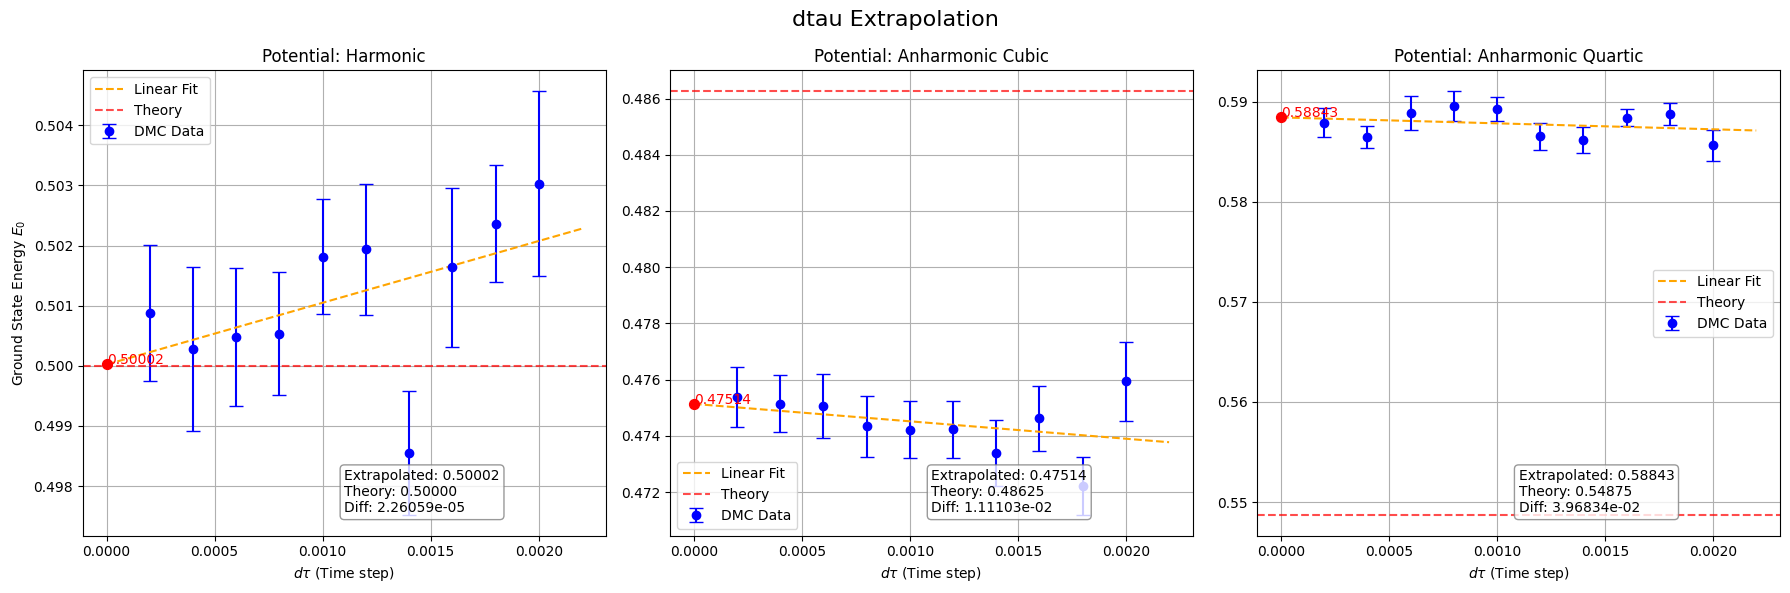

In [86]:
fig, axes = plt.subplots(1, len(V_list), figsize=(len(V_list)*6, 6), sharey=False)

for i, p in enumerate(V_list):
  coeffs = np.polyfit(dtau_list, results[p], 1)
  E_extrapolated = coeffs[1]
  x_fit = np.linspace(0, max(dtau_list) * 1.1, 100)
  y_fit = np.polyval(coeffs, x_fit)

  ax = axes[i]

  ax.errorbar(dtau_list, results[p], yerr=errors[p], fmt='o',
              color='blue', capsize=5, label='DMC Data')

  ax.plot(x_fit, y_fit, '--', color='orange', label='Linear Fit')
  ax.axhline(E0_theoric[p], color='red', linestyle='--', alpha=0.7, label='Theory')

  ax.scatter(0, E_extrapolated, color='red', zorder=5, s=50)
  ax.annotate(f"{E_extrapolated:.5f}", (0, E_extrapolated), color='red')

  ax.set_title(f"Potential: {p}")
  ax.set_xlabel(r"$d\tau$ (Time step)")
  if i == 0:
    ax.set_ylabel(r"Ground State Energy $E_0$")
  ax.grid()
  ax.legend()

  E0_theo = E0_theoric[p]
  diff = abs(E_extrapolated - E0_theo)
  text_info = (f"Extrapolated: {E_extrapolated:.5f}\n"
               f"Theory: {E0_theo:.5f}\n"
               f"Diff: {diff:.5e}")

  ax.text(0.5, 0.05, text_info, transform=ax.transAxes, fontsize=10,
          bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))
fig.suptitle("dtau Extrapolation", fontsize=16)
plt.tight_layout()
plt.show()

---

## Observation

### Harmonic Potential

For the harmonic oscillator, the results show excellent agreement with the exact theoretical value $ E_0 = 0.5 $. The linear extrapolation in $ \Delta\tau \to 0 $ converges almost perfectly, with a final discrepancy on the order of $ 10^{-5} $. This level of accuracy confirms both the correctness of the implementation and the expected linear behavior of the time-step bias.

The statistical uncertainties remain small and relatively uniform across different values of $ \Delta\tau $, indicating good stability of the simulation. Although minor fluctuations are visible in individual data points, they do not significantly affect the extrapolation due to the overall consistency of the dataset.

### Anharmonic Cubic Potential

In the cubic anharmonic case, the results exhibit a larger deviation from the theoretical prediction. The extrapolated ground state energy differs from the perturbative estimate by approximately $ 10^{-2} $.

Several factors contribute to this discrepancy. First, the cubic potential introduces an asymmetry and is not bounded from below, which can lead to instabilities in the walker population. This results in increased statistical noise and a less reliable sampling of configuration space. Additionally, the perturbative expression used for comparison is only valid for small values of the anharmonic parameter $ b $, which may further explain part of the observed deviation.

The data points show a moderate spread and a less clear linear trend compared to the harmonic case, indicating that the simulation is more sensitive to both stochastic fluctuations and systematic errors.

### Anharmonic Quartic Potential

For the quartic anharmonic potential, the results are more stable than in the cubic case but still exhibit a noticeable deviation from the theoretical value, also on the order of $ 10^{-2} $.

The quartic term leads to a stronger confinement of the walkers, which improves numerical stability compared to the cubic case. This is reflected in the relatively small error bars and the consistent clustering of data points. However, the extrapolated value remains systematically higher than the perturbative prediction.

This discrepancy can be attributed to two main effects: the increased sensitivity of the DMC algorithm to the time-step in steeper potentials, and the limited validity of the perturbative expansion at finite $ b $. Despite this, the linear behavior in $ \Delta\tau $ remains reasonably well defined, supporting the validity of the extrapolation procedure.

### Overall Assessment

The harmonic case validates the implementation, demonstrating that the DMC method accurately reproduces known analytical results when the system is well-behaved. In contrast, the anharmonic cases highlight the limitations of both the numerical method and the theoretical approximations used for comparison.

In particular:
- The time-step extrapolation works reliably when the simulation remains stable and the bias is approximately linear.
- Anharmonic potentials introduce stronger fluctuations and potential instabilities, increasing both statistical and systematic errors.
- The comparison with perturbative results must be interpreted cautiously, especially for larger values of the anharmonic parameter.

Overall, the results confirm that the DMC method is robust for simple systems and remains qualitatively accurate for more complex potentials, while requiring careful parameter tuning and interpretation in the anharmonic regime.

---

# Conclusion

In this project, a Diffusion Quantum Monte Carlo (DMC) algorithm was implemented and applied to the study of three one-dimensional quantum systems: the harmonic potential, and two anharmonic cases with cubic and quartic corrections. As a first experience with Quantum Monte Carlo methods, this work provided both a practical and conceptual introduction to stochastic approaches in quantum mechanics.

The simulations successfully reproduced the expected physical behavior of the systems. In particular, the evolution of the walker population and the reference energy $ V_{ref} $ demonstrated the core principles of the DMC method. The number of walkers fluctuated around the target population $N_0 $, while $V_{ref}$ stabilized around the ground state energy $E_0 $. Additionally, the spatial distribution of walkers was shown to converge toward the expected probability density, providing a direct visualization of the ground state wavefunction.

For the harmonic oscillator, the results were in excellent agreement with the exact analytical solution. This served as a strong validation of the implementation. In the anharmonic cases, the method remained stable and provided physically consistent results, although with larger deviations from the theoretical predictions. These discrepancies can be attributed both to the increased numerical difficulty of the problem and to the limitations of the perturbative expressions used for comparison.

A key aspect of this project was the analysis of time-step bias through extrapolation in the limit $\Delta\tau \to 0$. This procedure significantly improved the accuracy of the estimated ground state energies and highlighted the importance of controlling systematic errors in Monte Carlo simulations. The extrapolated values were consistent with theoretical expectations within the estimated uncertainties.

Overall, this project demonstrates that the Diffusion Monte Carlo method is a powerful and flexible tool for studying quantum systems, even with relatively simple implementations. At the same time, it illustrates the challenges associated with stochastic simulations, such as population control, numerical stability, and bias correction.

As a first project in Quantum Monte Carlo, this work lays a solid foundation for more advanced developments, such as importance sampling, higher-dimensional systems, or many-body problems.